In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
MAX_VID_LENGTH = 100

In [3]:
patients = list(range(1, 62))
patients.remove(23)

quadrants = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectFpr, f_classif

In [5]:
#VALENCE

def get_label(path):
    q = path.split("_")[0]

    if q in ["Q1", "Q4", "Q7"]:
        return "Negative Valence"
    
    if q in ["Q2", "Q5", "Q8"]:
        return "Neutral Valence"
    
    else:
        return "Positive Valence"

In [6]:
def cut_relevant_au(df, quadrant):

    if quadrant == "Q1_2":

        df = df[(df[" timestamp"] >= 20) & (df[" timestamp"] <= MAX_VID_LENGTH)]

    elif quadrant == "Q3_2":

        df = df[(df[" timestamp"] >= 38) & (df[" timestamp"] <= MAX_VID_LENGTH)]
    
    return df


In [7]:
def compute_au_features(patient, quadrant):

    path = rf"C:\Users\mique\OneDrive\Dokumenty\GitHub\POS\Gesture Emotion Prediction\Results\{patient}\{quadrant}\vid_crop.csv"

    df = pd.read_csv(path)

    # keep only valid frames
    if "success" in df.columns:
        df = df[df["success"] == 1]

    df = cut_relevant_au(df, quadrant)

    features = {}

    # select AU intensity columns
    au_cols = [c for c in df.columns if "_r" in c]

    for col in au_cols:
        features[f"{col}_mean"] = df[col].mean()
        # features[f"{col}_std"] = df[col].std()
        # features[f"{col}_max"] = df[col].max()

    # for col in au_cols:
    #     features[f"{col}_mean"] = df[col].mean()
    #     features[f"{col}_std"] = df[col].std()
    #     features[f"{col}_max"] = df[col].max()

    return features


In [8]:
data = []
labels = []
groups = [] 

for patient in patients:

    patient = f"Patient_{patient}"

    print(f"Computing Features for {patient}...", end="\r", flush=True)

    for quadrant in quadrants:

        features = compute_au_features(patient, quadrant)

        # example label extraction
        label = get_label(quadrant)   # Q1, Q2, Q3...

        id = f"{patient}{quadrant}"

        data.append(features)
        labels.append(label)
        groups.append(id)

X = pd.DataFrame(data)
y = np.array(labels) 

print()
print("Dataset shape:", X.shape)

print(np.unique(y, return_counts=True))
print("Example of data:", X.iloc[0])

Computing Features for Patient_61...
Dataset shape: (1080, 17)
(array(['Negative Valence', 'Neutral Valence', 'Positive Valence'],
      dtype='<U16'), array([360, 360, 360], dtype=int64))
Example of data: AU01_r_mean    0.283856
AU02_r_mean    0.187121
AU04_r_mean    0.788090
AU05_r_mean    0.042799
AU06_r_mean    0.725284
AU07_r_mean    0.366130
AU09_r_mean    0.057770
AU10_r_mean    1.490758
AU12_r_mean    0.942296
AU14_r_mean    1.009308
AU15_r_mean    0.197624
AU17_r_mean    0.299453
AU20_r_mean    0.065073
AU23_r_mean    0.089628
AU25_r_mean    0.264694
AU26_r_mean    0.399410
AU45_r_mean    0.423243
Name: 0, dtype: float64


In [9]:
feature_names = list(features.keys())

print(feature_names)

[' AU01_r_mean', ' AU02_r_mean', ' AU04_r_mean', ' AU05_r_mean', ' AU06_r_mean', ' AU07_r_mean', ' AU09_r_mean', ' AU10_r_mean', ' AU12_r_mean', ' AU14_r_mean', ' AU15_r_mean', ' AU17_r_mean', ' AU20_r_mean', ' AU23_r_mean', ' AU25_r_mean', ' AU26_r_mean', ' AU45_r_mean']


In [10]:
from sklearn.feature_selection import f_classif
import numpy as np

# X = feature matrix (n_samples, n_features)
# y = labels

F_values, p_values = f_classif(X, y)

# Combine everything
anova_results = list(zip(feature_names, F_values, p_values))

# Sort by F-score (descending)
anova_results.sort(key=lambda x: x[1], reverse=True)

# Print nicely
for name, f, p in anova_results:
    print(f"{name:15} | F = {f:.3f} | p = {p:.5f}")

 AU12_r_mean    | F = 30.406 | p = 0.00000
 AU25_r_mean    | F = 17.283 | p = 0.00000
 AU06_r_mean    | F = 17.262 | p = 0.00000
 AU09_r_mean    | F = 14.181 | p = 0.00000
 AU23_r_mean    | F = 12.186 | p = 0.00001
 AU10_r_mean    | F = 10.086 | p = 0.00005
 AU14_r_mean    | F = 7.885 | p = 0.00040
 AU17_r_mean    | F = 6.655 | p = 0.00134
 AU04_r_mean    | F = 6.313 | p = 0.00188
 AU07_r_mean    | F = 5.226 | p = 0.00551
 AU15_r_mean    | F = 3.607 | p = 0.02747
 AU20_r_mean    | F = 1.548 | p = 0.21322
 AU26_r_mean    | F = 1.418 | p = 0.24268
 AU05_r_mean    | F = 1.316 | p = 0.26859
 AU01_r_mean    | F = 1.078 | p = 0.34052
 AU02_r_mean    | F = 0.808 | p = 0.44586
 AU45_r_mean    | F = 0.038 | p = 0.96305


In [11]:
num_folds = 5
feat_p_cutoff = 0.05

In [12]:
from sklearn.feature_selection import SelectFpr, f_classif

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("anova", SelectFpr(score_func=f_classif, alpha=feat_p_cutoff)),  # FEATURE IMPORTANCE CUTOFF
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedGroupKFold(n_splits=num_folds)

classif_reports = []
conf_matrix = []
f1_scores = []

from collections import Counter
print("Class distribution:", Counter(y))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    print(f"Fold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    #print("Train dist:", Counter(y_train))
    #print("Test dist:", Counter(y_test))

    pipe.fit(X_train, y_train)

    # Access ANOVA step
    anova = pipe.named_steps["anova"]

    selected_mask = anova.get_support()
    selected_features = np.array(feature_names)[selected_mask]

    print("Selected features:", selected_features)
    #print("Num features:", len(selected_features))

    score = pipe.score(X_test, y_test)

    print("Score:", score)

    y_pred = pipe.predict(X_test)

    report_dict = classification_report(y_test, y_pred, output_dict=True)

    classif_reports.append(classification_report(y_test, y_pred))
    conf_matrix.append(confusion_matrix(y_test, y_pred))
    f1_scores.append(report_dict["macro avg"]["f1-score"])

print("-"*50)

print("F1-Scores:", [f"{score:.2f}" for score in f1_scores])
print()
print('\033[1m' + f"Average F1-Score: {sum(f1_scores)/num_folds}" + '\033[0m')
print()
for idx in range(num_folds):
    print(classif_reports[idx])
    print(conf_matrix[idx])
    print()
    print("-"*50)

Class distribution: Counter({'Negative Valence': 360, 'Neutral Valence': 360, 'Positive Valence': 360})
Fold 0
Selected features: [' AU04_r_mean' ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean'
 ' AU10_r_mean' ' AU12_r_mean' ' AU14_r_mean' ' AU17_r_mean'
 ' AU23_r_mean' ' AU25_r_mean']
Score: 0.4074074074074074
Fold 1
Selected features: [' AU04_r_mean' ' AU05_r_mean' ' AU06_r_mean' ' AU07_r_mean'
 ' AU09_r_mean' ' AU10_r_mean' ' AU12_r_mean' ' AU14_r_mean'
 ' AU17_r_mean' ' AU23_r_mean' ' AU25_r_mean']
Score: 0.37037037037037035
Fold 2
Selected features: [' AU04_r_mean' ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean'
 ' AU10_r_mean' ' AU12_r_mean' ' AU14_r_mean' ' AU15_r_mean'
 ' AU17_r_mean' ' AU23_r_mean' ' AU25_r_mean']
Score: 0.4074074074074074
Fold 3
Selected features: [' AU04_r_mean' ' AU06_r_mean' ' AU07_r_mean' ' AU09_r_mean'
 ' AU10_r_mean' ' AU12_r_mean' ' AU14_r_mean' ' AU17_r_mean'
 ' AU23_r_mean' ' AU25_r_mean']
Score: 0.39351851851851855
Fold 4
Selected features: [' AU04_r_mean

In [13]:
from sklearn.feature_selection import f_classif
import numpy as np

# X = feature matrix (n_samples, n_features)
# y = labels

F_values, p_values = f_classif(X, y)

# Combine everything
anova_results = list(zip(feature_names, F_values, p_values))

# Sort by F-score (descending)
anova_results.sort(key=lambda x: x[1], reverse=True)

# Print nicely
for name, f, p in anova_results:
    print(f"{name:15} | F = {f:.3f} | p = {p:.5f}")

 AU12_r_mean    | F = 30.406 | p = 0.00000
 AU25_r_mean    | F = 17.283 | p = 0.00000
 AU06_r_mean    | F = 17.262 | p = 0.00000
 AU09_r_mean    | F = 14.181 | p = 0.00000
 AU23_r_mean    | F = 12.186 | p = 0.00001
 AU10_r_mean    | F = 10.086 | p = 0.00005
 AU14_r_mean    | F = 7.885 | p = 0.00040
 AU17_r_mean    | F = 6.655 | p = 0.00134
 AU04_r_mean    | F = 6.313 | p = 0.00188
 AU07_r_mean    | F = 5.226 | p = 0.00551
 AU15_r_mean    | F = 3.607 | p = 0.02747
 AU20_r_mean    | F = 1.548 | p = 0.21322
 AU26_r_mean    | F = 1.418 | p = 0.24268
 AU05_r_mean    | F = 1.316 | p = 0.26859
 AU01_r_mean    | F = 1.078 | p = 0.34052
 AU02_r_mean    | F = 0.808 | p = 0.44586
 AU45_r_mean    | F = 0.038 | p = 0.96305


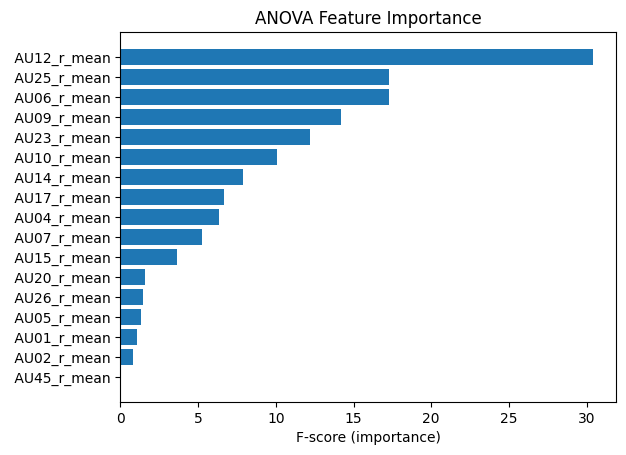

In [14]:
import matplotlib.pyplot as plt

# Sort again for plotting
names = [x[0] for x in anova_results]
f_scores = [x[1] for x in anova_results]

plt.figure()
plt.barh(names, f_scores)
plt.xlabel("F-score (importance)")
plt.title("ANOVA Feature Importance")
plt.gca().invert_yaxis()
plt.show()

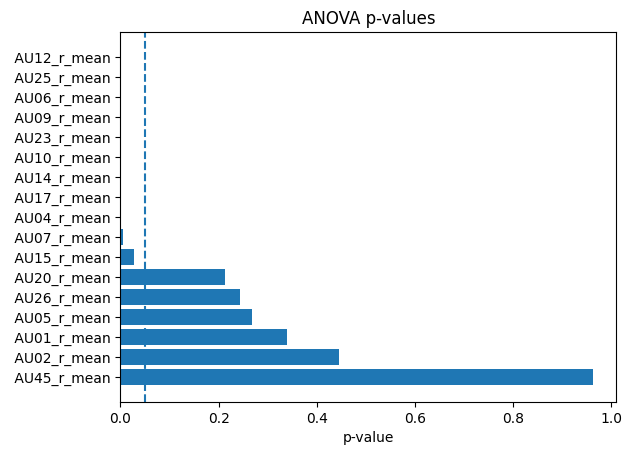

In [15]:
p_vals = [x[2] for x in anova_results]

plt.figure()
plt.barh(names, p_vals)
plt.xlabel("p-value")
plt.title("ANOVA p-values")
plt.gca().invert_yaxis()

# Optional: significance line
plt.axvline(x=0.05, linestyle='--')
plt.show()